# 4.7.3. 특수 매개 변수
* https://docs.python.org/ko/3.9/tutorial/controlflow.html#special-parameters

revisit
함수를 정의할 때 /와 *기호를 써서 매개 변수의 종류를 명확히 지정할 수 있습니다.

매개 변수는 3가지 종류가 있습니다.
* 위치 전용 (positional only)
* 위치-키워드 (positional or keyword)
* 키워드 전용 (keyword only)

```text
def f(pos1, pos2, /, pos_or_kwd, *, kwd1, kwd2):
      ----------     ----------     ----------
   positional only        |         keyword only
                          |
               positional or keyword
```

* \* 위치 전용 매개 변수는 / 앞에 있습니다. 

개발자가 위치, 위치-키워드, 키워드로 전달되는지 판단할 때, 함수 정의만 보면 되도록, 인자가 전달될 방법을 제한하면 좋습니다.



review
#### 4.7.3.1. 위치-키워드 인자 (positional or keyword)
함수 정의에 /와 *가 없으면 인자를 위치나 키워드로 함수에 전달할 수 있습니다.

#### 4.7.3.2. 위치 전용 매개 변수 (positional only)
* 특정 매개 변수를 위치 전용으로 표시할 수 있습니다.
* 위치 전용이면 매개 변수의 순서가 중요합니다.
* 키워드로 매개 변수를 전달할 수 없습니다.

##### (위치 전용 vs. 키워드 전용) 선택 지침
* 위치 전용 매개 변수
  * 함수 호출 시 매개 변수의 이름을 사용할 수 없도록 할 때 쓰임니다.
     * 매개 변수 이름이 실제 의미가 없을 떄
     * 함수가 호출될 때, 인자의 순서를 강제하려고 할 때
     * 일부 위치 매개 변수와 임의의 키워드를 받아들이고 싶을 때
  * (API의 경우) 향후 매개 변수의 이름이 수정될 때, 
      * 비호환 API변경이 발생하는 것을 방지하고 싶을 때
* 키워드 전용 매개 변수
  * 매개 변수 이름이 의미가 있을 때
  * (함수 정의가 이름을) 명시적으로 지정했을 때 더 이해하기 쉬울 때
  * 전달되는 인자의 위치에 의존하지 못 하게 할 때

### 4.7.3.3. 키워드 전용 인자
revisit

#### 4.7.3.4. 함수 예제
```python
def standard_arg(arg):
    print(arg)

def pos_only_arg(arg, /):
    print(arg)

def kwd_only_arg(*, arg):
    print(arg)

def combined_example(pos_only, /, standard, *, kwd_only):
    print(pos_only, standard, kwd_only)
```

In [ ]:
# 가장 익숙한 형식으로 호출 규칙에 아무런 제한이 없습니다.
#   그러므로 인자는 위치나 키워드로 전달 될 수 있습니다.

def standard_arg(arg):
    print(arg)

standard_arg(2)
standard_arg(arg=2)

2
2


In [ ]:
# /가 있으므로 position only입니다.

이것은 구글 코랩의 코드 셀에선 에러가 발생합니다.


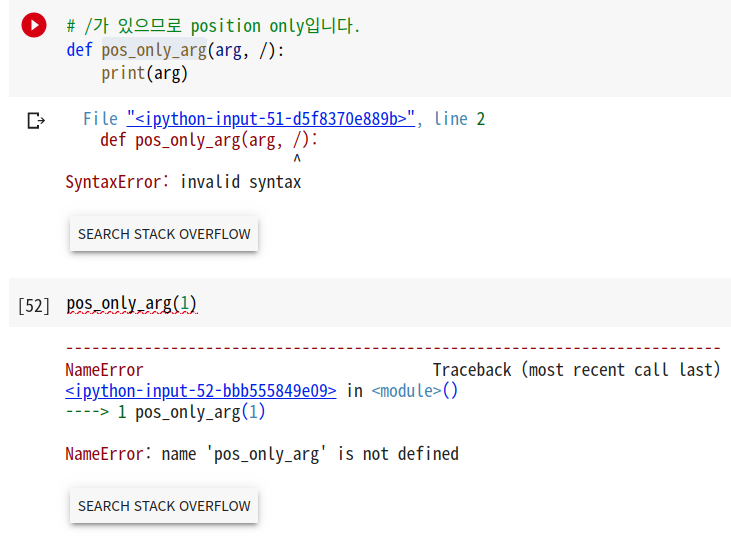

하지만 우분투 20.04의 터미널에선 정상 동작합니다.
```python
$ python
Python 3.8.5 (default, Sep  4 2020, 07:30:14) 
[GCC 7.3.0] :: Anaconda, Inc. on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> def pos_only_arg(arg, /):
...     print(arg)
... 
>>> pos_only_arg(1)
1
>>> 
```

In [ ]:
# *가 있으므로 키워드 인자만 허용합니다.
def kwd_only_arg(*, arg):
    print(arg)

kwd_only_arg(arg=3)

3


In [ ]:
# keyword_only인 아래는 에러가 발생합니다.
kwd_only_arg(3)

TypeError: ignored

In [ ]:
# 마지막은 세 가지 호출 규칙 모두를 사용합니다.

이것도 구글 코랩의 코드 셀에서 에러가 발생합니다.

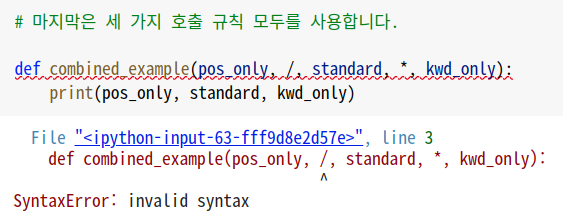

대신 우분투 20.04의 터미널에서 정상 동작합니다.
```python
$ python
Python 3.8.5 (default, Sep  4 2020, 07:30:14) 
[GCC 7.3.0] :: Anaconda, Inc. on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> def combined_example(pos_only, /, standard, *, kwd_only):
...     print(pos_only, standard, kwd_only)
... 
>>> combined_example(1, 2, kwd_only=3)
1 2 3
>>> 
```


In [ ]:
#   마지막으로, 위치 인자 name과 name을 키로 가지는 **kwds 사이에 잠재적인 충돌이 있는 이 함수 정의를 고려하십시오:

In [ ]:
# revisit 
def foo(name, **kwds):
    return 'name' in kwds

# 이 함수는 만약 kwds의 값에 'name'이 있으면 True를 리턴하기를 원합니다. 
# (하지만) True를 반환할 수 있는 호출은 불가능합니다.
# 왜냐하면 'name' 키워드는 항상 첫 번째 매개변수에 결합하기 때문입니다.

In [ ]:
# 예를 들면
foo(1, **{'name': 2})
# 의 경우, name=1이 되고, 
# 두 번째 'name'이 2가 되므로
# 'name'이 multiple values를 가지게 됩니다. 

TypeError: ignored

그러나 / (위치 전용 인자)를 사용하면 가능해집니다.

name을 위치 인자로, 동시에 'name'을 키워드 인자의 키로 사용할 수 있기 때문입니다.

아래의  파이썬 코드를
```python
def foo(name, /, **kwds):
    return 'name' in kwds
```
구글 코랩의 코드 셀에서 실행하면 에러가 발생하므로 

```bash
  File "<ipython-input-3-06f2cdf6997c>", line 4
    def foo(name, /, **kwds):
                  ^
SyntaxError: invalid syntax
```
대신 우분투 리눅스의 터미널에서 실행한 결과를 첨부합니다.
```bash
$ python
Python 3.8.5 (default, Sep  4 2020, 07:30:14) 
[GCC 7.3.0] :: Anaconda, Inc. on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> def foo(name, /, **kwds):
...   return 'name' in kwds
... 
>>> foo(1, **{'name': 2})
True
>>> foo(1, **{'tone': 2})
False
>>> 
```
의도한 대로 'name'이 있으면 True, 대신 'tone'가 있는 경우엔 False를 리턴했습니다.



#### 4.7.3.5. 복습
함수를 정의할 때 /와 *기호를 써서 매개 변수의 종류를 명확히 지정할 수 있습니다.

매개 변수는 3가지 종류가 있습니다.
* 위치 전용 (positional only)
* 위치-키워드 (positional or keyword)
* 키워드 전용 (keyword only)

```text
def f(pos1, pos2, /, pos_or_kwd, *, kwd1, kwd2):
      ----------     ----------     ----------
   positional only        |         keyword only
                          |
               positional or keyword
```

지침으로
* 위치 전용 매개 변수
  * 함수 호출 시 매개 변수의 이름을 사용할 수 없도록 할 때 쓰임니다.
     * 매개 변수 이름이 실제 의미가 없을 떄
     * 함수가 호출될 때, 인자의 순서를 강제하려고 할 때
     * 일부 위치 매개 변수와 임의의 키워드를 받아들이고 싶을 때
  * (API의 경우) 향후 매개 변수의 이름이 수정될 때, 
      * 비호환 API변경이 발생하는 것을 방지하고 싶을 때
* 키워드 전용 매개 변수
  * 매개 변수 이름이 의미가 있을 때
  * (함수 정의가 이름을) 명시적으로 지정했을 때 더 이해하기 쉬울 때
  * 전달되는 인자의 위치에 의존하지 못 하게 할 때